In [1]:
import pathlib as p
import pandas as pd
from architector import convert_io_molecule,view_structures
import matplotlib.pyplot as plt
import numpy as np

In [2]:
d = p.Path('outputs')
df_names = [x.name.replace('.pkl','') for x in d.glob('*pkl')]
fails = [x.name.replace('.pkl','') for x in d.glob('*failed.txt')]
dfs = [pd.read_pickle(x) for x in d.glob('*pkl')]

In [29]:
!squeue -u mgt16

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
            327575 chirality arch_mpi    mgt16  R      41:03      5 knot-[1-5]


In [30]:
print(len(dfs),len(fails))

225 17


In [19]:
pd.concat(dfs).shape[0] * 100

77600

In [20]:
ns = [df.shape[0] for df in dfs]

Text(0, 0.5, 'Counts')

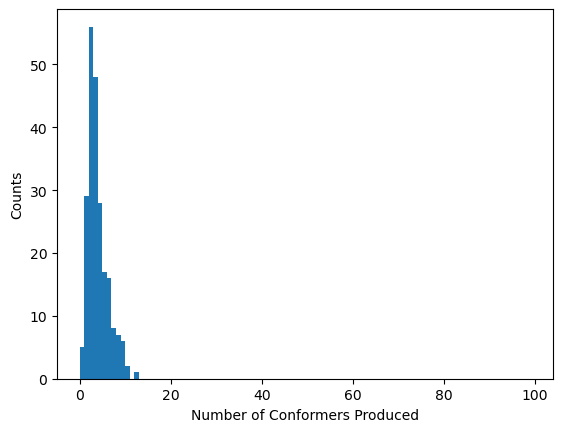

In [26]:
plt.hist(ns, bins=np.arange(0,100,1))
plt.xlabel('Number of Conformers Produced')
plt.ylabel('Counts')

In [27]:
view_structures(dfs[20]['mol2string'])

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

In [25]:
dfs[10].iloc[1]

total_charge                                                                     -1
xtb_n_unpaired_electrons                                                          1
calc_n_unpaired_electrons                                                         1
xtb_total_charge                                                                 -1
metal_ox                                                                          2
init_energy                                                            -2361.364066
energy                                                                 -2361.364066
metal_center_symmetry                                          trigonal_bipyramidal
metal_center_confidence                                                    0.093811
mol2string                        @<TRIPOS>MOLECULE\nsquare_pyramidal_1_nunpaire...
init_mol2string                                                                None
energy_sorted_index                                                         

In [13]:
xyzs = []
labels = []
for i,row in dfs[0].iterrows():
    mol = convert_io_molecule(row['mol2string'])
    # mol.uhf is the number of unpaired electrons in the molecule
    # multiplicity = n_unpaired electrons + 1
    label = '{}_{}_{}_{}.xyz'.format(df_names[0],i,str(int(mol.charge)),str(int(mol.uhf + 1))) 
    xyz = mol.write_xyz(label,
                        writestring=True) # Change to False to write out file.
    labels.append(label)
    xyzs.append(xyz)

In [14]:
view_structures(xyzs,labels=labels)

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol